In [60]:
import os
import numpy as np
import tifffile
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import czifile
import xml.etree.ElementTree as ET
from scipy import ndimage
from czifile import imread

# =========================================================
# CONFIGURATION -- edit everything here, nothing below
# =========================================================
input_folder = r"\\z-sv-dfsroot\dfsroot\project\ag-serwane\Data\Retina\Mouse\RxGFP\2026\RxGFP_r26a_p24\experiments\LSM\20260806_mESC_RxGFP_r26a_P24_DIV25_RGC_ImmunostainingsTest"
image_filename = r"20260806mESCRxGFPP24R26aDIV25O11830568WGA633DAPI40xKGMMzstack-03.czi"

image_path = os.path.join(input_folder, image_filename)

Z_STEP_FALLBACK_UM = 1.0   # used only if the file has no Z scaling (2D acquisition)

# =========================================================
# VOXEL GEOMETRY FROM CZI METADATA
# -----------------------------------------------------------------
# czifile's metadata() returns either a dict (newer versions, via
# asdict=True) or an XML string (older versions). This tries the
# dict form first and falls back to parsing the XML, so the cell
# works regardless of which version is installed.
#
# CZI stores scaling in metres; 1e6 converts to micrometres.
# =========================================================
xy_pixel_um = None
z_step_um = None

with czifile.CziFile(image_path) as czi:
    czi_shape = czi.shape
    czi_axes = getattr(czi, "axes", None)

    items = None
    try:
        meta = czi.metadata(asdict=True)
        items = meta["ImageDocument"]["Metadata"]["Scaling"]["Items"]["Distance"]
        print("Metadata read as dict.")
    except TypeError:
        # older czifile: metadata() takes no arguments and returns XML
        meta_xml = czi.metadata()
        if isinstance(meta_xml, bytes):
            meta_xml = meta_xml.decode("utf-8", errors="ignore")
        root = ET.fromstring(meta_xml)
        print("Metadata read as XML.")

        items = []
        for dist in root.iter("Distance"):
            axis_id = dist.get("Id")
            value_el = dist.find("Value")
            if axis_id and value_el is not None and value_el.text:
                items.append({"Id": axis_id, "Value": float(value_el.text)})

    print("\n=== SCALING ENTRIES FOUND ===")
    if not items:
        print("  (none)")
    for item in items:
        print(f"  {item['Id']}: {item['Value']:.3e} m  ->  {item['Value']*1e6:.4f} um")
        if item["Id"] in ("X", "Y"):
            xy_pixel_um = item["Value"] * 1e6
        elif item["Id"] == "Z":
            z_step_um = item["Value"] * 1e6

print(f"\nCZI shape: {czi_shape}")
if czi_axes:
    print(f"CZI axes : {czi_axes}")

if xy_pixel_um is None:
    raise ValueError("No X/Y scaling found in the CZI metadata -- cannot proceed.")

if z_step_um is None:
    print(f"\nNOTE: no Z scaling found -- this is likely a 2D (single-plane) acquisition.")
    print(f"      z_step_um set to {Z_STEP_FALLBACK_UM} um as a placeholder.")
    print(f"      Volume-based analysis downstream is not meaningful for 2D data.")
    z_step_um = Z_STEP_FALLBACK_UM
    is_3d = False
else:
    is_3d = True

print(f"\nScaling xy: {xy_pixel_um:.4f} um   Scaling z: {z_step_um:.4f} um")

# --- expected cell size ---
expected_cell_diameter_um = 4.0        # <-- adjust to your cell type

# --- Cellpose ---
model_type = "cpsam_v2"
use_gpu = True

# --- labels for outputs ---
condition_label = "Brn3a / WGA633 / DAPI"
cell_line = "RxGFP"

output_dir = os.path.dirname(os.path.abspath(image_path)) or "."
base_name = os.path.splitext(os.path.basename(image_path))[0]

print(f"\nVoxel size   : {xy_pixel_um:.3f} x {xy_pixel_um:.3f} x {z_step_um:.3f} um")
print(f"3D data      : {is_3d}")
print(f"Output folder: {output_dir}")

Metadata read as XML.

=== SCALING ENTRIES FOUND ===
  X: 4.143e-07 m  ->  0.4143 um
  Y: 4.143e-07 m  ->  0.4143 um

CZI shape: (1, 1, 4, 1, 512, 512, 1)
CZI axes : HTCZYX0

NOTE: no Z scaling found -- this is likely a 2D (single-plane) acquisition.
      z_step_um set to 1.0 um as a placeholder.
      Volume-based analysis downstream is not meaningful for 2D data.

Scaling xy: 0.4143 um   Scaling z: 1.0000 um

Voxel size   : 0.414 x 0.414 x 1.000 um
3D data      : False
Output folder: \\z-sv-dfsroot\dfsroot\project\ag-serwane\Data\Retina\Mouse\RxGFP\2026\RxGFP_r26a_p24\experiments\LSM\20260806_mESC_RxGFP_r26a_P24_DIV25_RGC_ImmunostainingsTest


In [61]:
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
import matplotlib.font_manager as fm

# =========================================================
# SCALE BAR HELPER -- reused on every image panel below
# -----------------------------------------------------------------
# Picks the best-looking round length (from a fixed candidate list)
# that's roughly 18% of the panel's current field of view, then
# draws it as a plain white bar with no background box. Call this
# right after each imshow(), passing the pixel size (in um) that's
# actually correct for that panel -- xy_pixel_um for raw/unbinned
# images, xy_pixel_um_eff for anything shown after binning.
# =========================================================
_SCALE_BAR_CANDIDATES_UM = np.array(
    [1, 2, 5, 10, 15, 20, 25, 50, 75, 100, 150, 200, 250, 500, 750, 1000]
)


def add_scale_bar(ax, pixel_size_um, location="lower right", color="white"):
    xlim = ax.get_xlim()
    width_um = abs(xlim[1] - xlim[0]) * pixel_size_um
    target_um = width_um * 0.18
    bar_um = _SCALE_BAR_CANDIDATES_UM[
        np.argmin(np.abs(_SCALE_BAR_CANDIDATES_UM - target_um))
    ]
    bar_px = bar_um / pixel_size_um

    fontprops = fm.FontProperties(size=10)
    scalebar = AnchoredSizeBar(
        ax.transData, bar_px, f"{bar_um:g} um", location,
        pad=0.5, color=color, frameon=False,
        size_vertical=bar_px * 0.06, fontproperties=fontprops,
    )
    ax.add_artist(scalebar)
    return scalebar


print("Scale bar helper ready (uses xy_pixel_um / xy_pixel_um_eff).")

Scale bar helper ready (uses xy_pixel_um / xy_pixel_um_eff).


In [62]:
img = imread(image_path).squeeze()
print("Loaded shape:", img.shape)
print("dtype:", img.dtype)
print("Size in RAM: %.2f GB" % (img.nbytes / 1e9))
print("ndim:", img.ndim)

Loaded shape: (4, 512, 512)
dtype: uint8
Size in RAM: 0.00 GB
ndim: 3


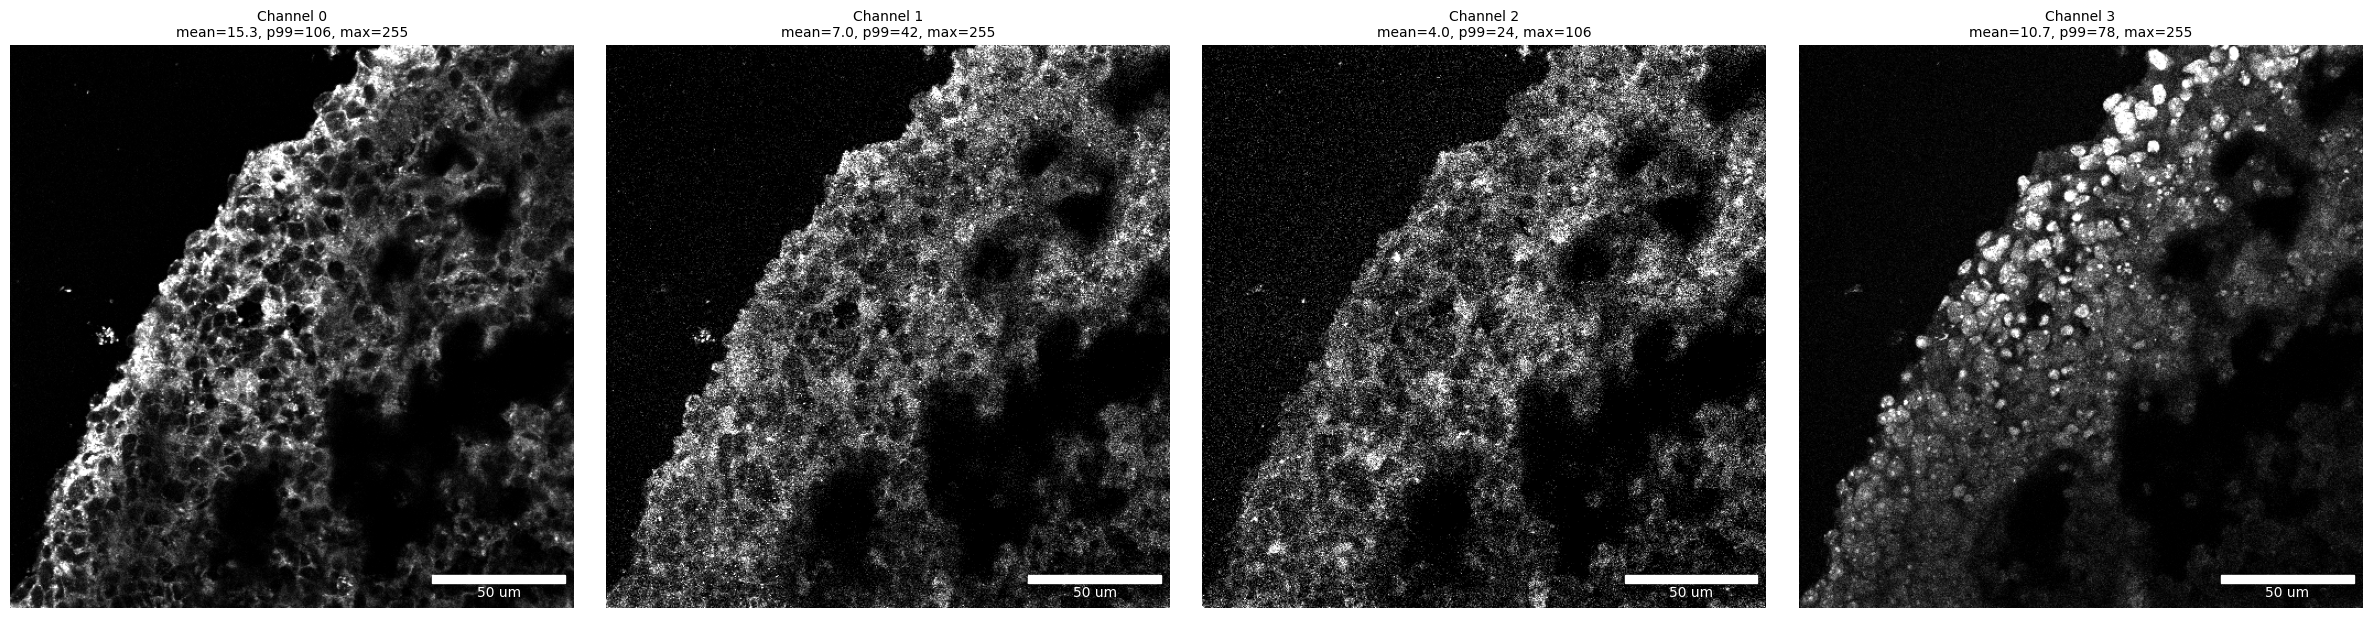

In [63]:
# =========================================================
# CHANNEL INSPECTION -- with scale bars
# -----------------------------------------------------------------
# add_scale_bar() is called once per panel, immediately after
# imshow(). xy_pixel_um is used (not xy_pixel_um_eff) because these
# are the raw, unbinned images.
# =========================================================
n_channels = img.shape[0]

fig, axes = plt.subplots(1, n_channels, figsize=(6 * n_channels, 6))
if n_channels == 1:
    axes = [axes]

color = ["grey", "grey", "grey", "gray"]

for c in range(n_channels):
    plane = img[c]

    # collapse any leading singleton axes (e.g. a size-1 z or time axis)
    plane = np.squeeze(plane)
    if plane.ndim == 3:                 # still a z-stack -> take the middle plane
        plane = plane[plane.shape[0] // 2]

    axes[c].imshow(plane, cmap=color[c % len(color)],
                   vmin=np.percentile(plane, 1), vmax=np.percentile(plane, 99))
    axes[c].set_title(
        f"Channel {c}\nmean={plane.mean():.1f}, "
        f"p99={np.percentile(plane, 99):.0f}, max={plane.max():.0f}",
        fontsize=10)
    axes[c].axis("off")

    add_scale_bar(axes[c], xy_pixel_um)      # <-- scale bar added here

plt.tight_layout()
plt.show()